# Cross-Lingual Persona Consistency in LLMs
### Analysis Notebook

This notebook loads the evaluation CSVs produced by `evaluate.py` and generates
all plots and tables for the study.

**Models compared:**
- `small` → Llama-3.1-8B-Instant
- `large` → Llama-3.3-70B-Versatile

**Metrics:**
- Sentiment polarity ([-1, +1])
- Formality score ([0, 1] composite of TTR + avg word length)
- Cross-lingual consistency (mean pairwise cosine similarity)


In [9]:
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

# ── Style ─────────────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.15)
PALETTE   = {'small': '#4C72B0', 'large': '#DD8452'}
LANG_PAL  = {'en': '#55A868', 'de': '#C44E52', 'it': '#8172B2'}
PERSONA_ORDER = ['neutral', 'pessimist', 'scientist', 'teenager']
FIG_DIR = Path('figures')
FIG_DIR.mkdir(exist_ok=True)
print('Setup OK')

Setup OK


## 1. Load Data

In [10]:
# ── Load flat CSVs (sentiment + formality, one row per response) ──────────────
flat_files = glob.glob('../outputs/eval_flat_responses_*.csv')
print(f'Found {len(flat_files)} flat eval files:')
for f in flat_files: print(f'  {f}')

df_flat = pd.concat([pd.read_csv(f) for f in flat_files], ignore_index=True)
print(f'\nTotal rows: {len(df_flat)}')
print(f'Models    : {df_flat["model"].unique()}')
df_flat.head(3)

Found 2 flat eval files:
  ../outputs/eval_flat_responses_large_20260510_141023.csv
  ../outputs/eval_flat_responses_small_20260509_141416.csv

Total rows: 480
Models    : <StringArray>
['large', 'small']
Length: 2, dtype: str


,model,groq_model_id,persona,category,language,question_index,question,response,latency_s,sentiment_label,sentiment_score,ttr,avg_word_len,formality_score
0,large,llama-3.3-70b-versatile,neutral,future_society,en,0,What do you think the world will look like in ...,Predicting the future with certainty is challe...,1.21,neutral,0.1836,0.6827,6.0769,0.6625
1,large,llama-3.3-70b-versatile,neutral,future_society,en,1,Will artificial intelligence make human worker...,The impact of artificial intelligence (AI) on ...,1.28,neutral,-0.0584,0.5612,5.3249,0.3808
2,large,llama-3.3-70b-versatile,neutral,future_society,en,2,How should society deal with growing inequality?,Dealing with growing inequality is a complex i...,1.34,neutral,0.2547,0.5314,5.8117,0.3876


In [11]:
# ── Load consistency CSVs (one row per persona x category x question group) ───
cons_files = glob.glob('../outputs/eval_consistency_responses_*.csv')
df_cons = pd.concat([pd.read_csv(f) for f in cons_files], ignore_index=True)
print(f'Consistency rows: {len(df_cons)}')
df_cons.head(3)

Consistency rows: 160


,model,persona,category,question_index,response_en,response_de,response_it,cos_en_de,cos_en_it,cos_de_it,consistency
0,large,neutral,abstract,0,The question of the meaning of life is a profo...,"**Der Sinn des Lebens: Eine Frage, die Mensche...",**Il Senso della Vita: Una Domanda Eterna**\n\...,0.8234,0.7883,0.9039,0.8385
1,large,neutral,abstract,1,The question of whether free will truly exists...,**Die Frage nach dem freien Willen: Eine kompl...,**Il libero arbitrio: un dibattito filosofico*...,0.9020,0.6410,0.6782,0.7404
2,large,neutral,abstract,2,The question of whether morality is objective ...,**Die Frage nach der Objektivität der Moral**\...,**Introduzione**\n\nLa questione della moralit...,0.9092,0.8612,0.8929,0.8878


## 2. Sentiment Analysis

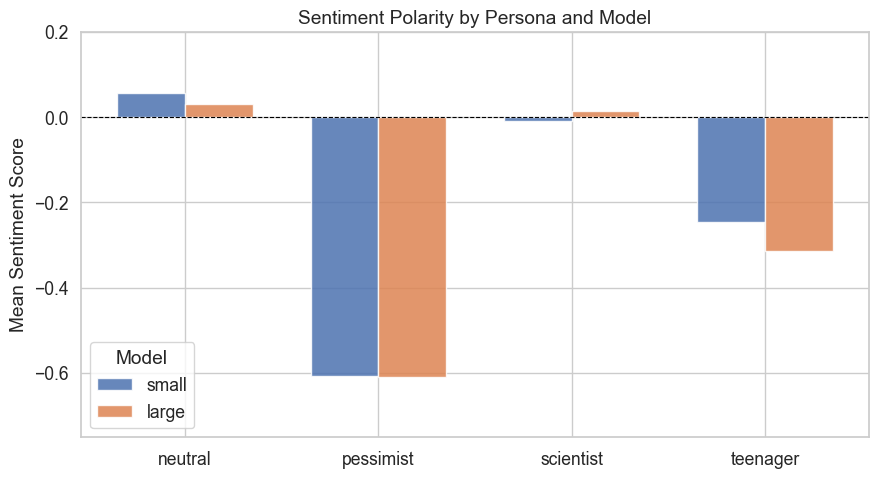

In [12]:
# ── 2a. Sentiment by persona x model ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))

pivot = (
    df_flat.groupby(['persona', 'model'])['sentiment_score']
    .mean()
    .unstack('model')
    .reindex(PERSONA_ORDER)
)

x     = np.arange(len(PERSONA_ORDER))
width = 0.35
for i, model in enumerate(['small', 'large']):
    ax.bar(x + i*width, pivot[model], width, label=model,
           color=PALETTE[model], alpha=0.85, edgecolor='white')

ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xticks(x + width/2)
ax.set_xticklabels(PERSONA_ORDER)
ax.set_ylabel('Mean Sentiment Score')
ax.set_title('Sentiment Polarity by Persona and Model')
ax.legend(title='Model')
ax.set_ylim(-0.75, 0.20)
plt.tight_layout()
plt.savefig(FIG_DIR / 'sentiment_persona_model.png', dpi=150)
plt.show()

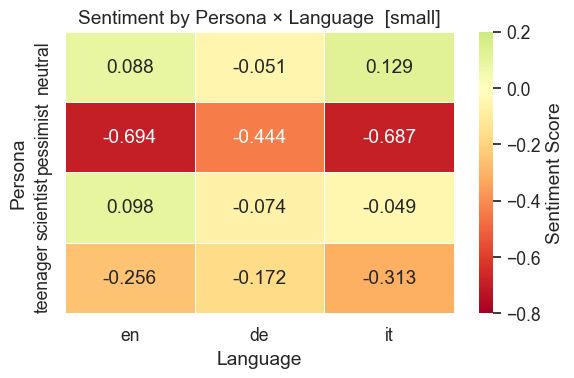

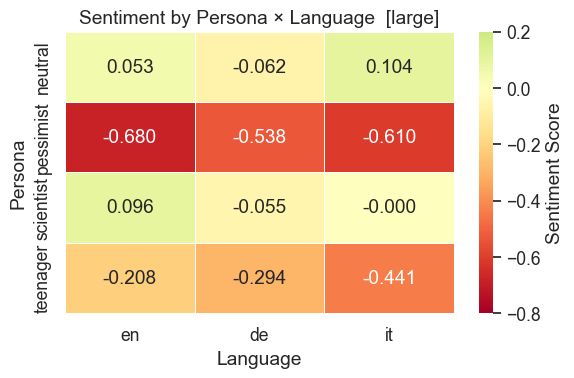

In [13]:
# ── 2b. Sentiment by language x persona (heatmap) ────────────────────────────
for model in ['small', 'large']:
    pivot = (
        df_flat[df_flat['model'] == model]
        .groupby(['persona', 'language'])['sentiment_score']
        .mean()
        .unstack('language')
        .reindex(PERSONA_ORDER)[['en', 'de', 'it']]
    )
    fig, ax = plt.subplots(figsize=(6, 4))
    sns.heatmap(
        pivot, annot=True, fmt='.3f', cmap='RdYlGn',
        center=0, vmin=-0.8, vmax=0.2, ax=ax,
        linewidths=0.5, cbar_kws={'label': 'Sentiment Score'}
    )
    ax.set_title(f'Sentiment by Persona × Language  [{model}]')
    ax.set_xlabel('Language')
    ax.set_ylabel('Persona')
    plt.tight_layout()
    plt.savefig(FIG_DIR / f'sentiment_heatmap_{model}.png', dpi=150)
    plt.show()

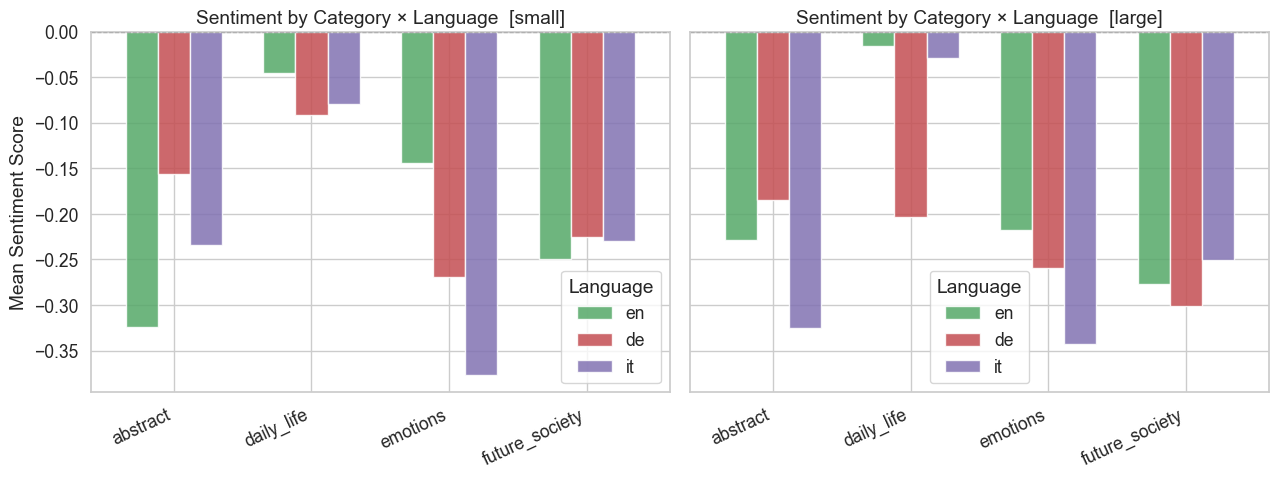

In [14]:
# ── 2c. Sentiment by language x category ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

for ax, model in zip(axes, ['small', 'large']):
    pivot = (
        df_flat[df_flat['model'] == model]
        .groupby(['category', 'language'])['sentiment_score']
        .mean()
        .unstack('language')[['en', 'de', 'it']]
    )
    pivot.plot(kind='bar', ax=ax, color=[LANG_PAL[l] for l in ['en','de','it']],
               alpha=0.85, edgecolor='white', width=0.7)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_title(f'Sentiment by Category × Language  [{model}]')
    ax.set_xlabel('')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha='right')
    ax.legend(title='Language')

axes[0].set_ylabel('Mean Sentiment Score')
plt.tight_layout()
plt.savefig(FIG_DIR / 'sentiment_category_language.png', dpi=150)
plt.show()

## 3. Formality Analysis

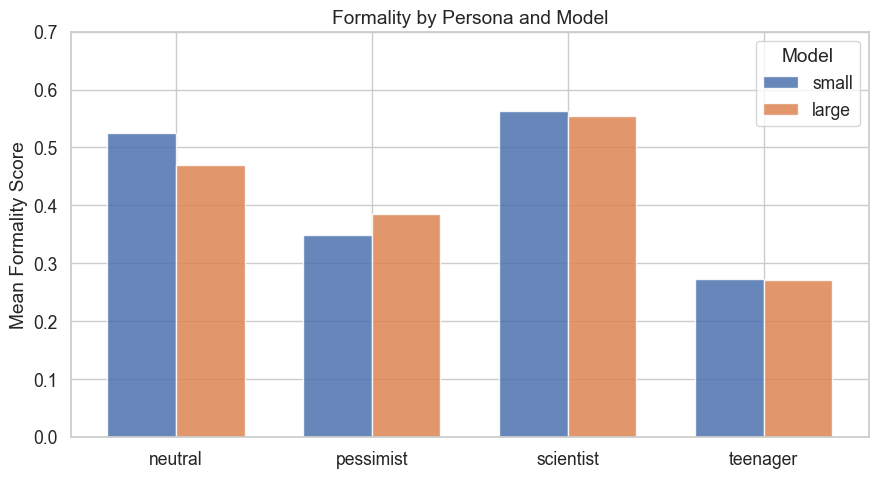

In [15]:
# ── 3a. Formality score by persona x model ───────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))

pivot = (
    df_flat.groupby(['persona', 'model'])['formality_score']
    .mean()
    .unstack('model')
    .reindex(PERSONA_ORDER)
)

x = np.arange(len(PERSONA_ORDER))
for i, model in enumerate(['small', 'large']):
    ax.bar(x + i*width, pivot[model], width, label=model,
           color=PALETTE[model], alpha=0.85, edgecolor='white')

ax.set_xticks(x + width/2)
ax.set_xticklabels(PERSONA_ORDER)
ax.set_ylabel('Mean Formality Score')
ax.set_title('Formality by Persona and Model')
ax.set_ylim(0, 0.7)
ax.legend(title='Model')
plt.tight_layout()
plt.savefig(FIG_DIR / 'formality_persona_model.png', dpi=150)
plt.show()

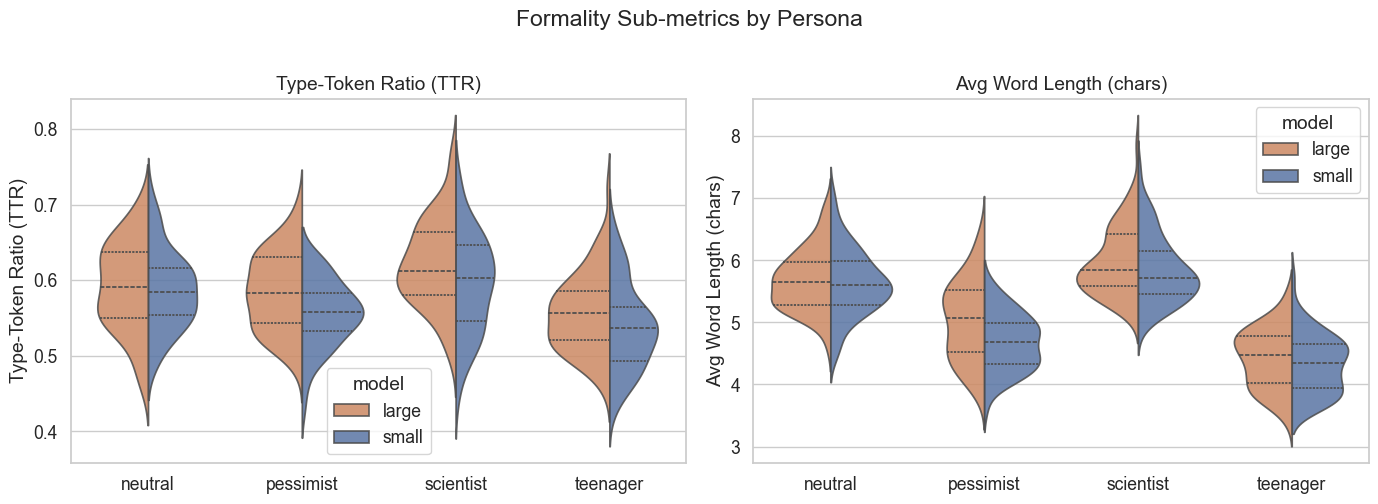

In [16]:
# ── 3b. TTR and avg_word_len distributions by persona (violin) ───────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, metric, label in zip(
    axes,
    ['ttr', 'avg_word_len'],
    ['Type-Token Ratio (TTR)', 'Avg Word Length (chars)']
):
    sns.violinplot(
        data=df_flat, x='persona', y=metric, hue='model',
        order=PERSONA_ORDER, palette=PALETTE,
        split=True, inner='quart', ax=ax, alpha=0.85
    )
    ax.set_title(label)
    ax.set_xlabel('')
    ax.set_ylabel(label)

plt.suptitle('Formality Sub-metrics by Persona', y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / 'formality_violin.png', dpi=150)
plt.show()

## 4. Cross-Lingual Consistency Analysis

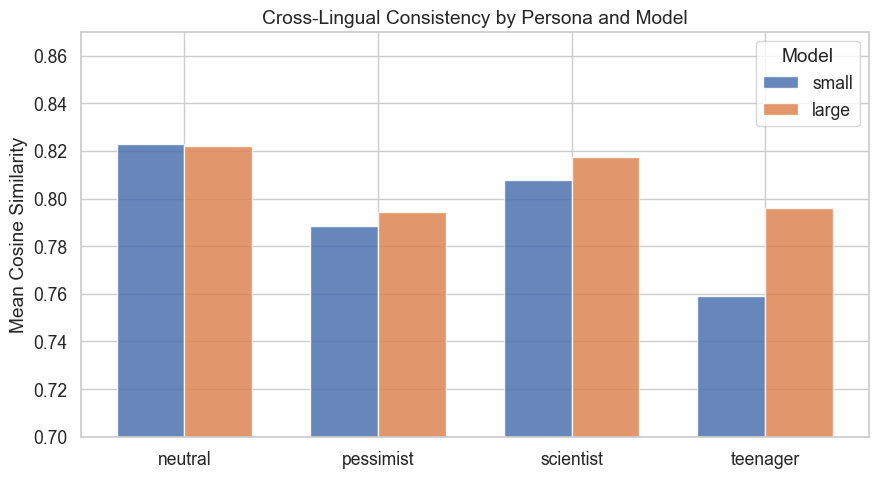

In [17]:
# ── 4a. Consistency by persona x model (bar) ─────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))

pivot = (
    df_cons.groupby(['persona', 'model'])['consistency']
    .mean()
    .unstack('model')
    .reindex(PERSONA_ORDER)
)

x = np.arange(len(PERSONA_ORDER))
for i, model in enumerate(['small', 'large']):
    ax.bar(x + i*width, pivot[model], width, label=model,
           color=PALETTE[model], alpha=0.85, edgecolor='white')

ax.set_xticks(x + width/2)
ax.set_xticklabels(PERSONA_ORDER)
ax.set_ylabel('Mean Cosine Similarity')
ax.set_title('Cross-Lingual Consistency by Persona and Model')
ax.set_ylim(0.70, 0.87)
ax.legend(title='Model')
plt.tight_layout()
plt.savefig(FIG_DIR / 'consistency_persona_model.png', dpi=150)
plt.show()

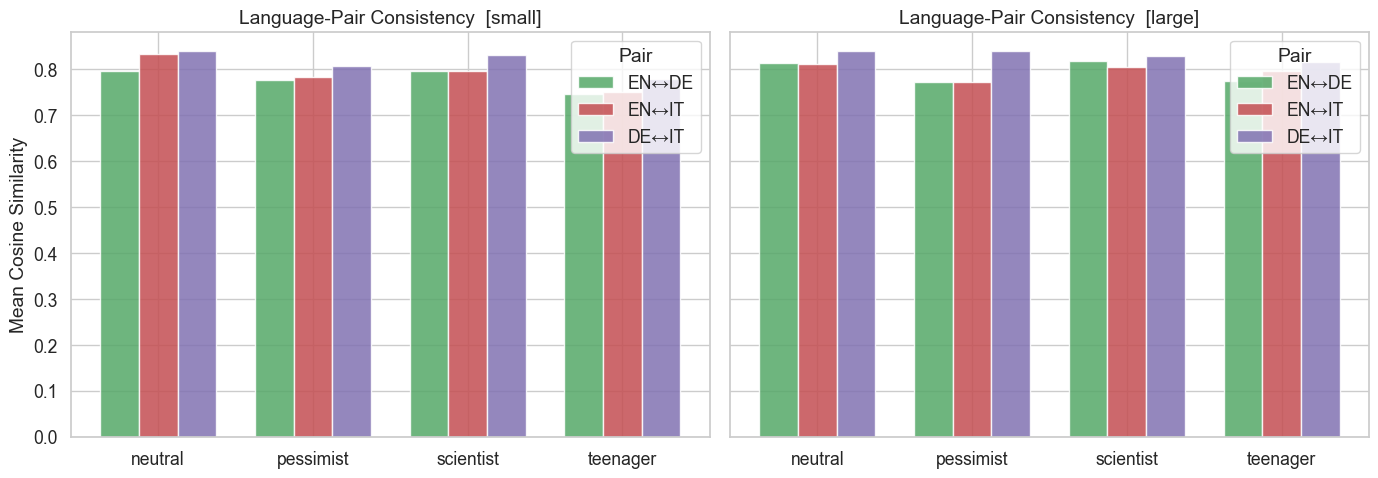

In [18]:
# ── 4b. Language-pair breakdown (en↔de, en↔it, de↔it) by persona ─────────────
pair_cols   = ['cos_en_de', 'cos_en_it', 'cos_de_it']
pair_labels = ['EN↔DE', 'EN↔IT', 'DE↔IT']

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, model in zip(axes, ['small', 'large']):
    sub = df_cons[df_cons['model'] == model]
    data = [
        sub.groupby('persona')[col].mean().reindex(PERSONA_ORDER)
        for col in pair_cols
    ]
    x = np.arange(len(PERSONA_ORDER))
    w = 0.25
    colors = ['#55A868', '#C44E52', '#8172B2']
    for j, (d, lbl, col) in enumerate(zip(data, pair_labels, colors)):
        ax.bar(x + j*w, d.values, w, label=lbl, color=col, alpha=0.85, edgecolor='white')
    ax.set_xticks(x + w)
    ax.set_xticklabels(PERSONA_ORDER)
    ax.set_title(f'Language-Pair Consistency  [{model}]')
    ax.set_xlabel('')
    ax.legend(title='Pair')

axes[0].set_ylabel('Mean Cosine Similarity')
plt.tight_layout()
plt.savefig(FIG_DIR / 'consistency_language_pairs.png', dpi=150)
plt.show()

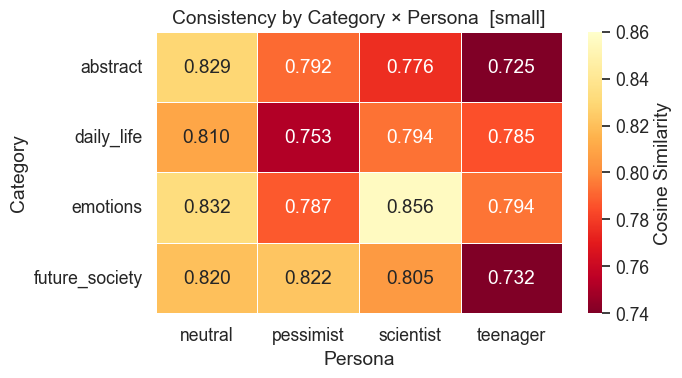

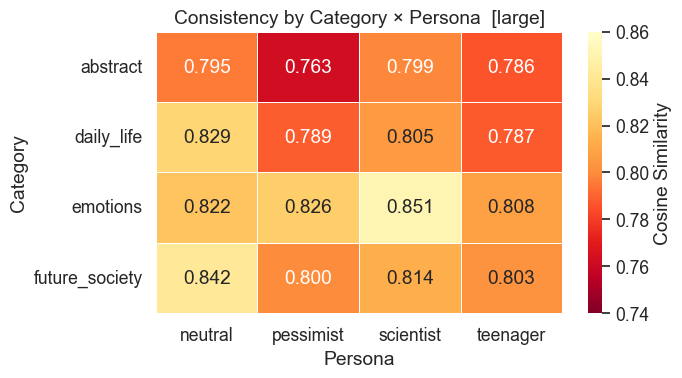

In [19]:
# ── 4c. Consistency by category x persona (heatmap, large model) ─────────────
for model in ['small', 'large']:
    pivot = (
        df_cons[df_cons['model'] == model]
        .groupby(['category', 'persona'])['consistency']
        .mean()
        .unstack('persona')
        .reindex(columns=PERSONA_ORDER)
    )
    fig, ax = plt.subplots(figsize=(7, 4))
    sns.heatmap(
        pivot, annot=True, fmt='.3f',
        cmap='YlOrRd_r', vmin=0.74, vmax=0.86,
        ax=ax, linewidths=0.5,
        cbar_kws={'label': 'Cosine Similarity'}
    )
    ax.set_title(f'Consistency by Category × Persona  [{model}]')
    ax.set_xlabel('Persona')
    ax.set_ylabel('Category')
    plt.tight_layout()
    plt.savefig(FIG_DIR / f'consistency_heatmap_{model}.png', dpi=150)
    plt.show()

## 5. Summary Table

In [21]:
# ── Full summary table: all metrics by persona x model ───────────────────────
agg_flat = (
    df_flat.groupby(['model', 'persona'])
    .agg(
        sentiment_mean  = ('sentiment_score',  'mean'),
        sentiment_std   = ('sentiment_score',  'std'),
        formality_mean  = ('formality_score',  'mean'),
        formality_std   = ('formality_score',  'std'),
        ttr_mean        = ('ttr',              'mean'),
        avg_word_len    = ('avg_word_len',      'mean'),
    )
    .round(3)
)

agg_cons = (
    df_cons.groupby(['model', 'persona'])
    .agg(consistency_mean = ('consistency', 'mean'),
         consistency_std  = ('consistency', 'std'))
    .round(3)
)

summary = agg_flat.join(agg_cons)
summary.to_csv('../outputs/summary_table.csv')
print('Summary table saved to outputs/summary_table.csv')
summary

Summary table saved to outputs/summary_table.csv


sentiment_mean  sentiment_std  formality_mean  formality_std  \
model persona                                                                   
large neutral             0.031          0.315           0.469          0.128   
      pessimist          -0.609          0.295           0.386          0.130   
      scientist           0.014          0.229           0.554          0.139   
      teenager           -0.314          0.520           0.271          0.121   
small neutral             0.056          0.305           0.525          0.133   
      pessimist          -0.608          0.280           0.349          0.101   
      scientist          -0.008          0.268           0.564          0.152   
      teenager           -0.247          0.504           0.272          0.124   

                 ttr_mean  avg_word_len  consistency_mean  consistency_std  
model persona                                                               
large neutral       0.591         5.680             0.822            0.053  
      pessimist     0.585         5.032             0.794            0.045  
      scientist     0.622         5.985             0.817            0.044  
      teenager      0.556         4.421             0.796            0.057  
small neutral       0.587         5.638             0.823            0.087  
      pessimist     0.556         4.683             0.789            0.075  
      scientist     0.593         5.851             0.808            0.065  
      teenager      0.538         4.322             0.759            0.092

## 6. Key Findings

Fill this in after reviewing your plots:

1. **Persona signal is strong**: pessimist and teenager show clearly negative/informal scores across both models and all three languages.
2. **Italian drift**: Italian responses show slightly lower sentiment scores — investigate whether this is persona-specific or uniform.
3. **Scale effect on consistency**: the 70B model is more consistent across languages for every persona, especially teenager.
4. **Teenager is the most vulnerable persona**: lowest consistency AND lowest formality — persona bleeds most in Italian.
5. **Category effects**: check which topic categories show the largest EN↔IT gap in the consistency heatmap.
